# AIMS 5790 — Additional Experiments (Part 2)

**Focus Areas**:
1. 🔄 Data Pruning (Redo) — 多种策略剪枝 + 评估
2. 📚 Influence-based Curriculum Learning — 基于 influence 排序的课程学习
3. 📐 Multi-Proof Impact Analysis — 同一定理多种证明的影响分析

**⚠️ Important**: This notebook only READS existing results from Part 1 and ADDS new experiments.
It does NOT modify any existing saved outputs.

---
## 0. Setup & Load Existing Results

In [3]:
!pip install -q -U transformers datasets peft trl accelerate bitsandbytes safetensors scipy scikit-learn matplotlib seaborn tqdm huggingface-hub pandas==2.2.2

In [4]:
import os, json, torch, numpy as np, pandas as pd, matplotlib.pyplot as plt, seaborn as sns
from collections import defaultdict
from tqdm import tqdm
from datasets import load_dataset, Dataset, interleave_datasets
from transformers import AutoModelForCausalLM, AutoTokenizer, BitsAndBytesConfig
from peft import LoraConfig, get_peft_model, prepare_model_for_kbit_training
from trl import SFTConfig, SFTTrainer
import warnings
warnings.filterwarnings('ignore')

os.environ["HF_ENDPOINT"] = "https://hf-mirror.com"
try:
    from google.colab import drive
    drive.mount("/content/drive")
    ROOT = "/content/drive/MyDrive/AIMS5790"
except ImportError:
    ROOT = "./AIMS5790_outputs"

os.makedirs(ROOT, exist_ok=True)
os.makedirs(ROOT + "/outputs/experiments_p2", exist_ok=True)
print(f"结果将保存到: {ROOT}")
print(f"CUDA: {torch.cuda.is_available()}")
if torch.cuda.is_available():
    print(f"Device: {torch.cuda.get_device_name(0)}")

Mounted at /content/drive
结果将保存到: /content/drive/MyDrive/AIMS5790
CUDA: True
Device: NVIDIA RTX PRO 6000 Blackwell Server Edition


In [5]:
# ===== Load existing influence scores =====
data = np.load(ROOT + "/outputs/influence_scores.npz")
influences = data["influences"]
top_idx = data["top_idx"]
bot_idx = data["bot_idx"]
print(f"Loaded influence scores: shape={influences.shape}")
print(f"  Range: [{influences.min():.2f}, {influences.max():.2f}]")
print(f"  Negative count: {(influences < 0).sum()} / {len(influences)}")
print(f"  Strongly negative (<-10000): {(influences < -10000).sum()}")

Loaded influence scores: shape=(8497,)
  Range: [-57908.62, 11216.17]
  Negative count: 5508 / 8497
  Strongly negative (<-10000): 647


In [6]:
# ===== Load training losses if available =====
train_losses = None
grads_path = ROOT + "/outputs/grads/train_grads.pt"
if os.path.exists(grads_path):
    train_losses = np.array(torch.load(grads_path)["losses"])
    print(f"Loaded train losses: shape={train_losses.shape}")
else:
    print(f"Warning: train losses not found at {grads_path}")

Loaded train losses: shape=(8497,)


In [7]:
# ===== Reload dataset (same pipeline as Part 1) =====
def filter_human_complete_proofs(ds, min_proof_len=20, min_statement_len=5):
    def _filter(ex):
        if ex.get("author") != "human": return False
        if ex.get("ground_truth_type") != "complete": return False
        proof = (ex.get("formal_ground_truth") or "").strip()
        stmt = (ex.get("formal_statement") or "").strip()
        if len(proof) < min_proof_len or len(stmt) < min_statement_len: return False
        if "sorry" in proof.lower(): return False
        return True
    return ds.filter(_filter)

def deduplicate(ds):
    seen, keep = set(), []
    for i in range(len(ds)):
        ex = ds[i]
        key = (ex.get("formal_statement", ""), ex.get("formal_ground_truth", ""))
        if key in seen: continue
        seen.add(key)
        keep.append(i)
    return ds.select(keep)

def format_sample(stmt, proof):
    return f"### Theorem:\n{stmt.strip()}\n\n### Proof:\n{proof.strip()}"

ds = load_dataset("AI-MO/NuminaMath-LEAN", split="train", trust_remote_code=True)
ds_filtered = filter_human_complete_proofs(ds)
ds_filtered = deduplicate(ds_filtered)

ds_split = ds_filtered.train_test_split(test_size=0.1, seed=42)
ds_val_test = ds_split["test"].train_test_split(test_size=0.5, seed=42)
ds_train = ds_split["train"]
ds_val = ds_val_test["train"]
ds_test = ds_val_test["test"]

def add_text(ex):
    ex["text"] = format_sample(ex["formal_statement"], ex["formal_ground_truth"])
    return ex

ds_train = ds_train.map(add_text, desc="Format")
ds_val = ds_val.map(add_text, desc="Format")
ds_test = ds_test.map(add_text, desc="Format")

print(f"Train: {len(ds_train)}, Val: {len(ds_val)}, Test: {len(ds_test)}")
assert len(ds_train) == len(influences), f"Mismatch: {len(ds_train)} vs {len(influences)}"

`trust_remote_code` is not supported anymore.
Please check that the Hugging Face dataset 'AI-MO/NuminaMath-LEAN' isn't based on a loading script and remove `trust_remote_code`.
If the dataset is based on a loading script, please ask the dataset author to remove it and convert it to a standard format like Parquet.
ERROR:datasets.load:`trust_remote_code` is not supported anymore.
Please check that the Hugging Face dataset 'AI-MO/NuminaMath-LEAN' isn't based on a loading script and remove `trust_remote_code`.
If the dataset is based on a loading script, please ask the dataset author to remove it and convert it to a standard format like Parquet.


README.md: 0.00B [00:00, ?B/s]

data/train-00000-of-00001.parquet:   0%|          | 0.00/78.4M [00:00<?, ?B/s]

Generating train split:   0%|          | 0/104155 [00:00<?, ? examples/s]

Filter:   0%|          | 0/104155 [00:00<?, ? examples/s]

Format:   0%|          | 0/8497 [00:00<?, ? examples/s]

Format:   0%|          | 0/472 [00:00<?, ? examples/s]

Format:   0%|          | 0/473 [00:00<?, ? examples/s]

Train: 8497, Val: 472, Test: 473


In [8]:
# ===== Config =====
CONFIG = {
    "MODEL_ID": "Qwen/Qwen2.5-0.5B-Instruct",
    "max_seq_length": 1024,
    "lora_r": 16, "lora_alpha": 32, "lora_dropout": 0.05,
    "epochs": 3, "batch_size": 1, "grad_accum": 8, "lr": 2e-4,
}

In [9]:
# ===== Utility: Train & Evaluate =====
def create_fresh_model():
    """Create a fresh QLoRA model"""
    bnb_config = BitsAndBytesConfig(
        load_in_4bit=True,
        bnb_4bit_compute_dtype="bfloat16",
        bnb_4bit_quant_type="nf4",
        bnb_4bit_use_double_quant=True,
    )
    base = AutoModelForCausalLM.from_pretrained(
        CONFIG["MODEL_ID"], quantization_config=bnb_config, device_map="auto", trust_remote_code=True,
    )
    tokenizer = AutoTokenizer.from_pretrained(CONFIG["MODEL_ID"], trust_remote_code=True)
    model = prepare_model_for_kbit_training(base)
    model = get_peft_model(
        model,
        LoraConfig(
            r=CONFIG["lora_r"], lora_alpha=CONFIG["lora_alpha"],
            lora_dropout=CONFIG["lora_dropout"], bias="none",
            target_modules=["q_proj","k_proj","v_proj","o_proj"],
            task_type="CAUSAL_LM"
        )
    )
    model.config.use_cache = False
    model.gradient_checkpointing_enable()
    model.enable_input_require_grads()
    return model, tokenizer


def train_and_evaluate(train_dataset, name, save_logs=True):
    """Train model on given dataset, return eval losses across epochs"""
    os.environ["PYTORCH_CUDA_ALLOC_CONF"] = "expandable_segments:True"
    torch.cuda.empty_cache()

    out = ROOT + f"/outputs/experiments_p2/{name}"
    os.makedirs(out, exist_ok=True)

    model, tokenizer = create_fresh_model()

    args = SFTConfig(
        output_dir=out,
        max_length=min(CONFIG["max_seq_length"], 1024),
        dataset_text_field="text",
        packing=False,
        num_train_epochs=CONFIG["epochs"],
        per_device_train_batch_size=1,
        per_device_eval_batch_size=1,
        gradient_accumulation_steps=CONFIG["grad_accum"],
        learning_rate=CONFIG["lr"],
        max_grad_norm=0.3, warmup_steps=50, lr_scheduler_type="cosine",
        logging_steps=10, save_strategy="epoch",
        bf16=True, eval_strategy="epoch", seed=42,
        load_best_model_at_end=True,
    )

    trainer = SFTTrainer(
        model=model, args=args,
        train_dataset=train_dataset, eval_dataset=ds_val,
    )

    trainer.train()
    trainer.save_model(f"{out}/adapter")

    # Extract eval losses
    eval_losses = [h["eval_loss"] for h in trainer.state.log_history if "eval_loss" in h]
    train_losses_hist = [h["loss"] for h in trainer.state.log_history if "loss" in h]

    result = {
        "name": name,
        "train_size": len(train_dataset),
        "val_loss_final": eval_losses[-1] if eval_losses else None,
        "val_loss_best": min(eval_losses) if eval_losses else None,
        "val_losses": eval_losses,
    }

    if save_logs:
        with open(f"{out}/result.json", "w") as f:
            json.dump(result, f, indent=2)

    # Free memory
    del model, trainer
    torch.cuda.empty_cache()

    return result


print("Utility functions defined.")

Utility functions defined.


---
## 1. 🔄 Data Pruning Experiments (Redo)

**Goal**: Systematically evaluate different data pruning strategies based on influence function.
For each strategy, we remove a subset of training data and compare performance.

### Strategies:
1. **Threshold pruning**: Remove samples with influence < threshold
2. **Percentage pruning**: Remove bottom K% by influence
3. **Loss-aware pruning**: Remove high-loss + negative influence samples
4. **Length-influence joint**: Remove short + strongly negative influence
5. **Soft pruning**: Keep all data but weight by influence (up/down sampling)

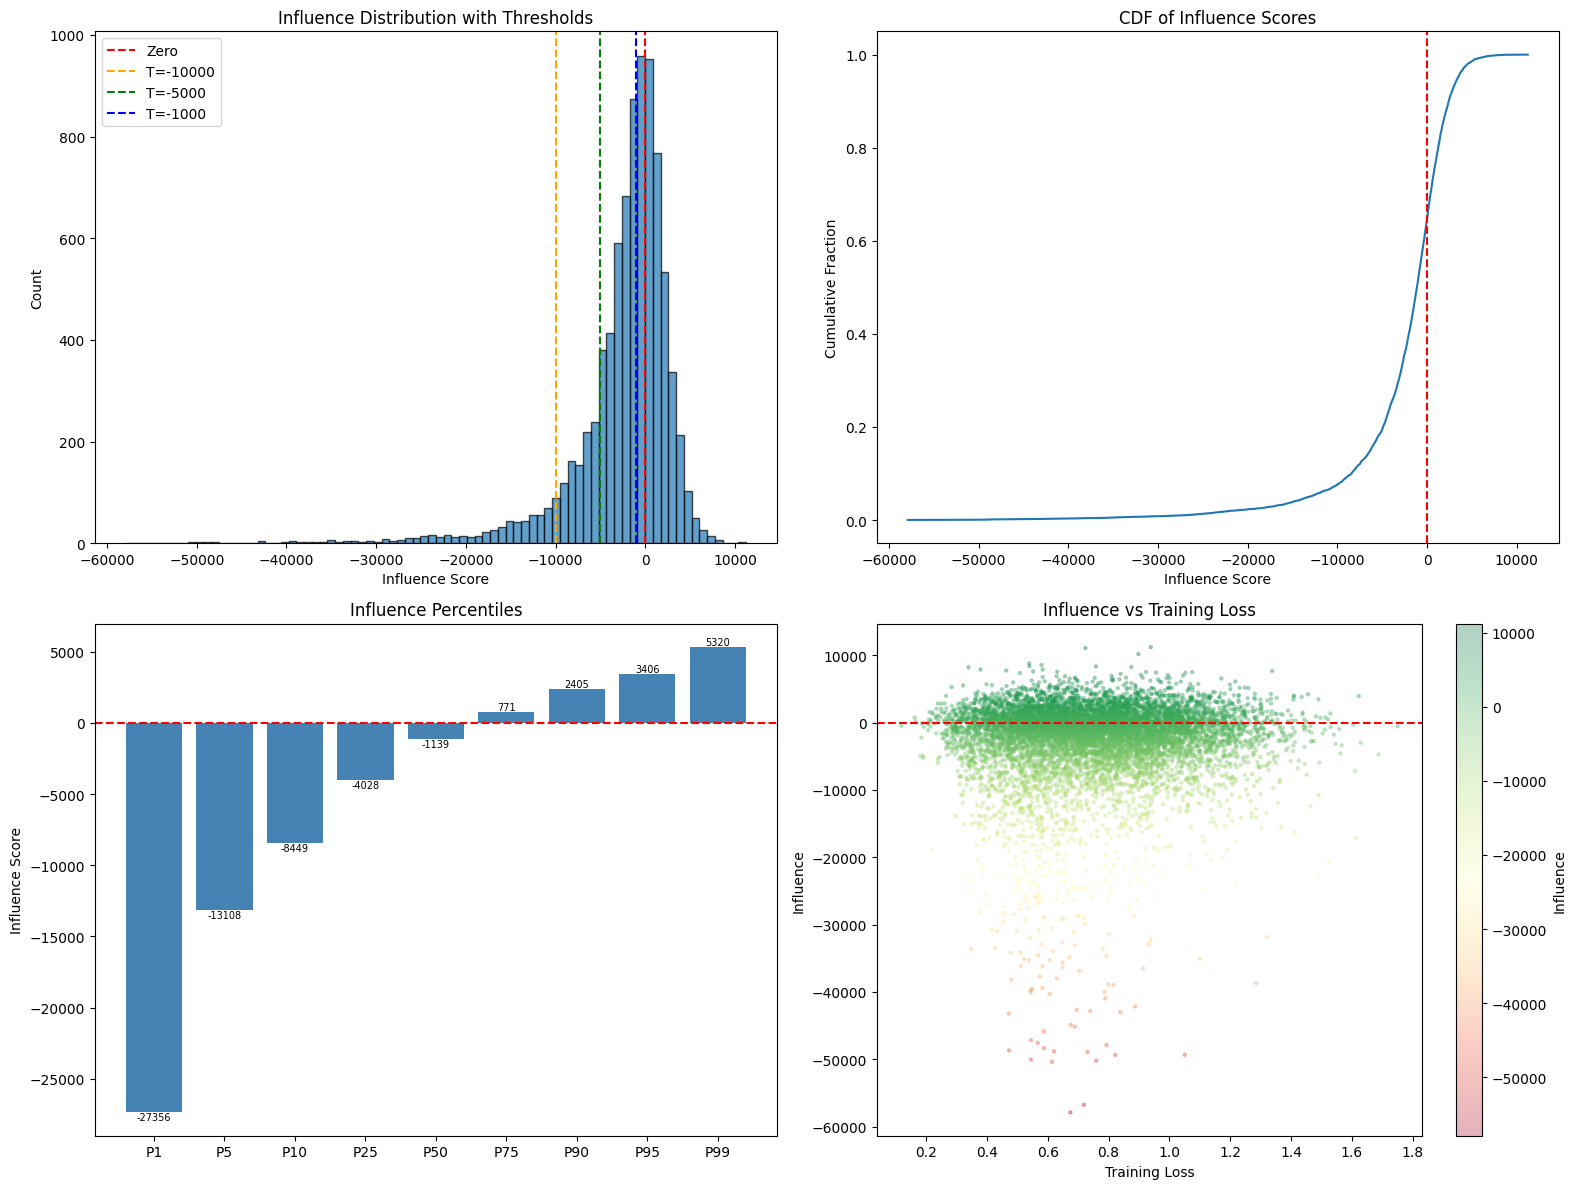

Saved influence analysis plot.


In [10]:
# ===== 1.1 Influence Distribution Analysis =====
fig, axes = plt.subplots(2, 2, figsize=(16, 12))

# 1. Histogram
axes[0, 0].hist(influences, bins=80, edgecolor='black', alpha=0.7)
axes[0, 0].axvline(x=0, color='red', linestyle='--', label='Zero')
axes[0, 0].axvline(x=-10000, color='orange', linestyle='--', label='T=-10000')
axes[0, 0].axvline(x=-5000, color='green', linestyle='--', label='T=-5000')
axes[0, 0].axvline(x=-1000, color='blue', linestyle='--', label='T=-1000')
axes[0, 0].set_title("Influence Distribution with Thresholds")
axes[0, 0].set_xlabel("Influence Score")
axes[0, 0].set_ylabel("Count")
axes[0, 0].legend()

# 2. CDF
sorted_inf = np.sort(influences)
cdf = np.arange(1, len(sorted_inf) + 1) / len(sorted_inf)
axes[0, 1].plot(sorted_inf, cdf)
axes[0, 1].axvline(x=0, color='red', linestyle='--')
axes[0, 1].set_title("CDF of Influence Scores")
axes[0, 1].set_xlabel("Influence Score")
axes[0, 1].set_ylabel("Cumulative Fraction")

# 3. Percentile thresholds
percentiles = [1, 5, 10, 25, 50, 75, 90, 95, 99]
vals = [np.percentile(influences, p) for p in percentiles]
axes[1, 0].bar([f"P{p}" for p in percentiles], vals, color='steelblue')
axes[1, 0].axhline(y=0, color='red', linestyle='--')
axes[1, 0].set_title("Influence Percentiles")
axes[1, 0].set_ylabel("Influence Score")
for i, v in enumerate(vals):
    axes[1, 0].text(i, v, f"{v:.0f}", ha='center', va='bottom' if v >= 0 else 'top', fontsize=7)

# 4. Influence vs Training Loss
if train_losses is not None:
    scatter = axes[1, 1].scatter(train_losses, influences, alpha=0.3, s=5, c=influences, cmap='RdYlGn')
    axes[1, 1].axhline(y=0, color='red', linestyle='--')
    axes[1, 1].set_title("Influence vs Training Loss")
    axes[1, 1].set_xlabel("Training Loss")
    axes[1, 1].set_ylabel("Influence")
    plt.colorbar(scatter, ax=axes[1, 1], label='Influence')
else:
    axes[1, 1].text(0.5, 0.5, "Training losses not available", ha='center', va='center', transform=axes[1, 1].transAxes)
    axes[1, 1].set_title("Influence vs Training Loss")

plt.tight_layout()
plt.savefig(ROOT + "/outputs/experiments_p2/influence_analysis.png", dpi=150)
plt.show()
print("Saved influence analysis plot.")

In [11]:
# ===== 1.2 Define Pruning Strategies =====

def get_lengths():
    return np.array([len(ds_train[i]["formal_ground_truth"]) for i in range(len(ds_train))])

lengths = get_lengths()

def strategy_threshold(threshold):
    """Remove all samples with influence < threshold"""
    keep = np.where(influences >= threshold)[0]
    return keep, f"threshold_{threshold}"

def strategy_bottom_pct(pct):
    """Remove bottom pct% by influence"""
    k = int(len(influences) * pct / 100)
    bottom_k = np.argsort(influences)[:k]
    keep = np.setdiff1d(np.arange(len(influences)), bottom_k)
    return keep, f"remove_bottom{int(pct)}pct"

def strategy_loss_influence(loss_threshold=0.9, influence_threshold=0, _train_losses=None):
    """Remove samples with high loss AND negative influence (likely noisy/harmful)"""
    tl = _train_losses if _train_losses is not None else globals().get('train_losses')
    if tl is None:
        print("Warning: train_losses not available, skipping loss-aware pruning")
        return np.arange(len(influences)), "loss_influence_skip"
    tl = np.array(tl) if not isinstance(tl, np.ndarray) else tl
    keep = np.where(~((tl > loss_threshold) & (influences < influence_threshold)))[0]
    return keep, f"loss>{loss_threshold}_inf<{influence_threshold}"

def strategy_length_influence(len_threshold=500, influence_threshold=0):
    """Remove short proofs with negative influence"""
    keep = np.where(~((lengths < len_threshold) & (influences < influence_threshold)))[0]
    return keep, f"len<{len_threshold}_inf<{influence_threshold}"

def strategy_combined_score(pct_remove=10, _train_losses=None):
    """Remove pct_remove% worst samples by combined score: influence * (1 - loss_norm)"""
    tl = _train_losses if _train_losses is not None else globals().get('train_losses')
    if tl is None:
        print("Warning: train_losses not available")
        return np.arange(len(influences)), "combined_skip"
    tl = np.array(tl) if not isinstance(tl, np.ndarray) else tl
    # Normalize losses to [0, 1]
    loss_norm = (tl - tl.min()) / (tl.max() - tl.min() + 1e-8)
    # Combined score: higher is better (high influence, low loss)
    score = influences * (1 - loss_norm)
    k = int(len(score) * pct_remove / 100)
    worst_k = np.argsort(score)[:k]
    keep = np.setdiff1d(np.arange(len(score)), worst_k)
    return keep, f"combined_remove{int(pct_remove)}pct"


# ===== Define all pruning experiments =====
pruning_experiments = [
    strategy_threshold(-10000),
    strategy_threshold(-5000),
    strategy_bottom_pct(10),
    strategy_loss_influence(0.9, 0),
    strategy_combined_score(10),
]

print("=== Pruning Strategy Summary ===")
for keep, name in pruning_experiments:
    removed = len(ds_train) - len(keep)
    pct = removed / len(ds_train) * 100
    print(f"  {name:35s} -> keep {len(keep):5d} / {len(ds_train)}, remove {removed:5d} ({pct:.1f}%)")

=== Pruning Strategy Summary ===
  threshold_-10000                    -> keep  7850 / 8497, remove   647 (7.6%)
  threshold_-5000                     -> keep  6838 / 8497, remove  1659 (19.5%)
  remove_bottom10pct                  -> keep  7648 / 8497, remove   849 (10.0%)
  loss>0.9_inf<0                      -> keep  6969 / 8497, remove  1528 (18.0%)
  combined_remove10pct                -> keep  7648 / 8497, remove   849 (10.0%)


In [12]:
# ===== 1.3 Run Data Pruning Experiments =====
pruning_results = {}

for keep_indices, name in pruning_experiments:
    print(f"\n{'='*60}")
    print(f"🔧 Pruning: {name}")
    print(f"  Keeping {len(keep_indices)} samples")

    # Create pruned dataset
    pruned_data = [ds_train[i] for i in keep_indices]
    pruned_ds = Dataset.from_list(pruned_data)

    # Add difficulty for consistency
    def add_difficulty(example):
        text = example["text"]
        example["difficulty"] = len(text) + 10 * text.count("\n") + 5 * text.count("=") + 5 * text.count("→")
        return example
    pruned_ds = pruned_ds.map(add_difficulty)

    # Train
    result = train_and_evaluate(pruned_ds, f"prune_{name}")
    pruning_results[name] = result

    print(f"  ✅ Best val loss: {result['val_loss_best']:.4f}, Final: {result['val_loss_final']:.4f}")

# Save summary
df_prune = pd.DataFrame([{
    "name": name,
    "train_size": r["train_size"],
    "removed_pct": (1 - r["train_size"]/len(ds_train))*100,
    "val_loss_best": r["val_loss_best"],
    "val_loss_final": r["val_loss_final"],
} for name, r in pruning_results.items()])
df_prune.to_csv(ROOT + "/outputs/experiments_p2/pruning_results.csv", index=False)
print("\n=== Pruning Results Summary ===")
print(df_prune.sort_values("val_loss_best").to_string())


🔧 Pruning: threshold_-10000
  Keeping 7850 samples


Map:   0%|          | 0/7850 [00:00<?, ? examples/s]

config.json:   0%|          | 0.00/659 [00:00<?, ?B/s]

model.safetensors:   0%|          | 0.00/988M [00:00<?, ?B/s]

Loading weights:   0%|          | 0/290 [00:00<?, ?it/s]

...

Adding EOS to train dataset:   0%|          | 0/7648 [00:00<?, ? examples/s]

Tokenizing train dataset:   0%|          | 0/7648 [00:00<?, ? examples/s]

The tokenizer has new PAD/BOS/EOS tokens that differ from the model config and generation config. The model config and generation config were aligned accordingly, being updated with the tokenizer's values. Updated tokens: {'bos_token_id': None, 'pad_token_id': 151643}.


Epoch,Training Loss,Validation Loss
1,0.850388,0.805735
2,0.834059,0.776323
3,0.771695,0.774010


  ✅ Best val loss: 0.7740, Final: 0.7740

=== Pruning Results Summary ===
                   name  train_size  removed_pct  val_loss_best  val_loss_final
0      threshold_-10000        7850     7.614452       0.771887        0.771887
4  combined_remove10pct        7648     9.991762       0.774010        0.774010
2    remove_bottom10pct        7648     9.991762       0.774506        0.774506
1       threshold_-5000        6838    19.524538       0.781613        0.781613
3        loss>0.9_inf<0        6969    17.982817       0.781696        0.781696


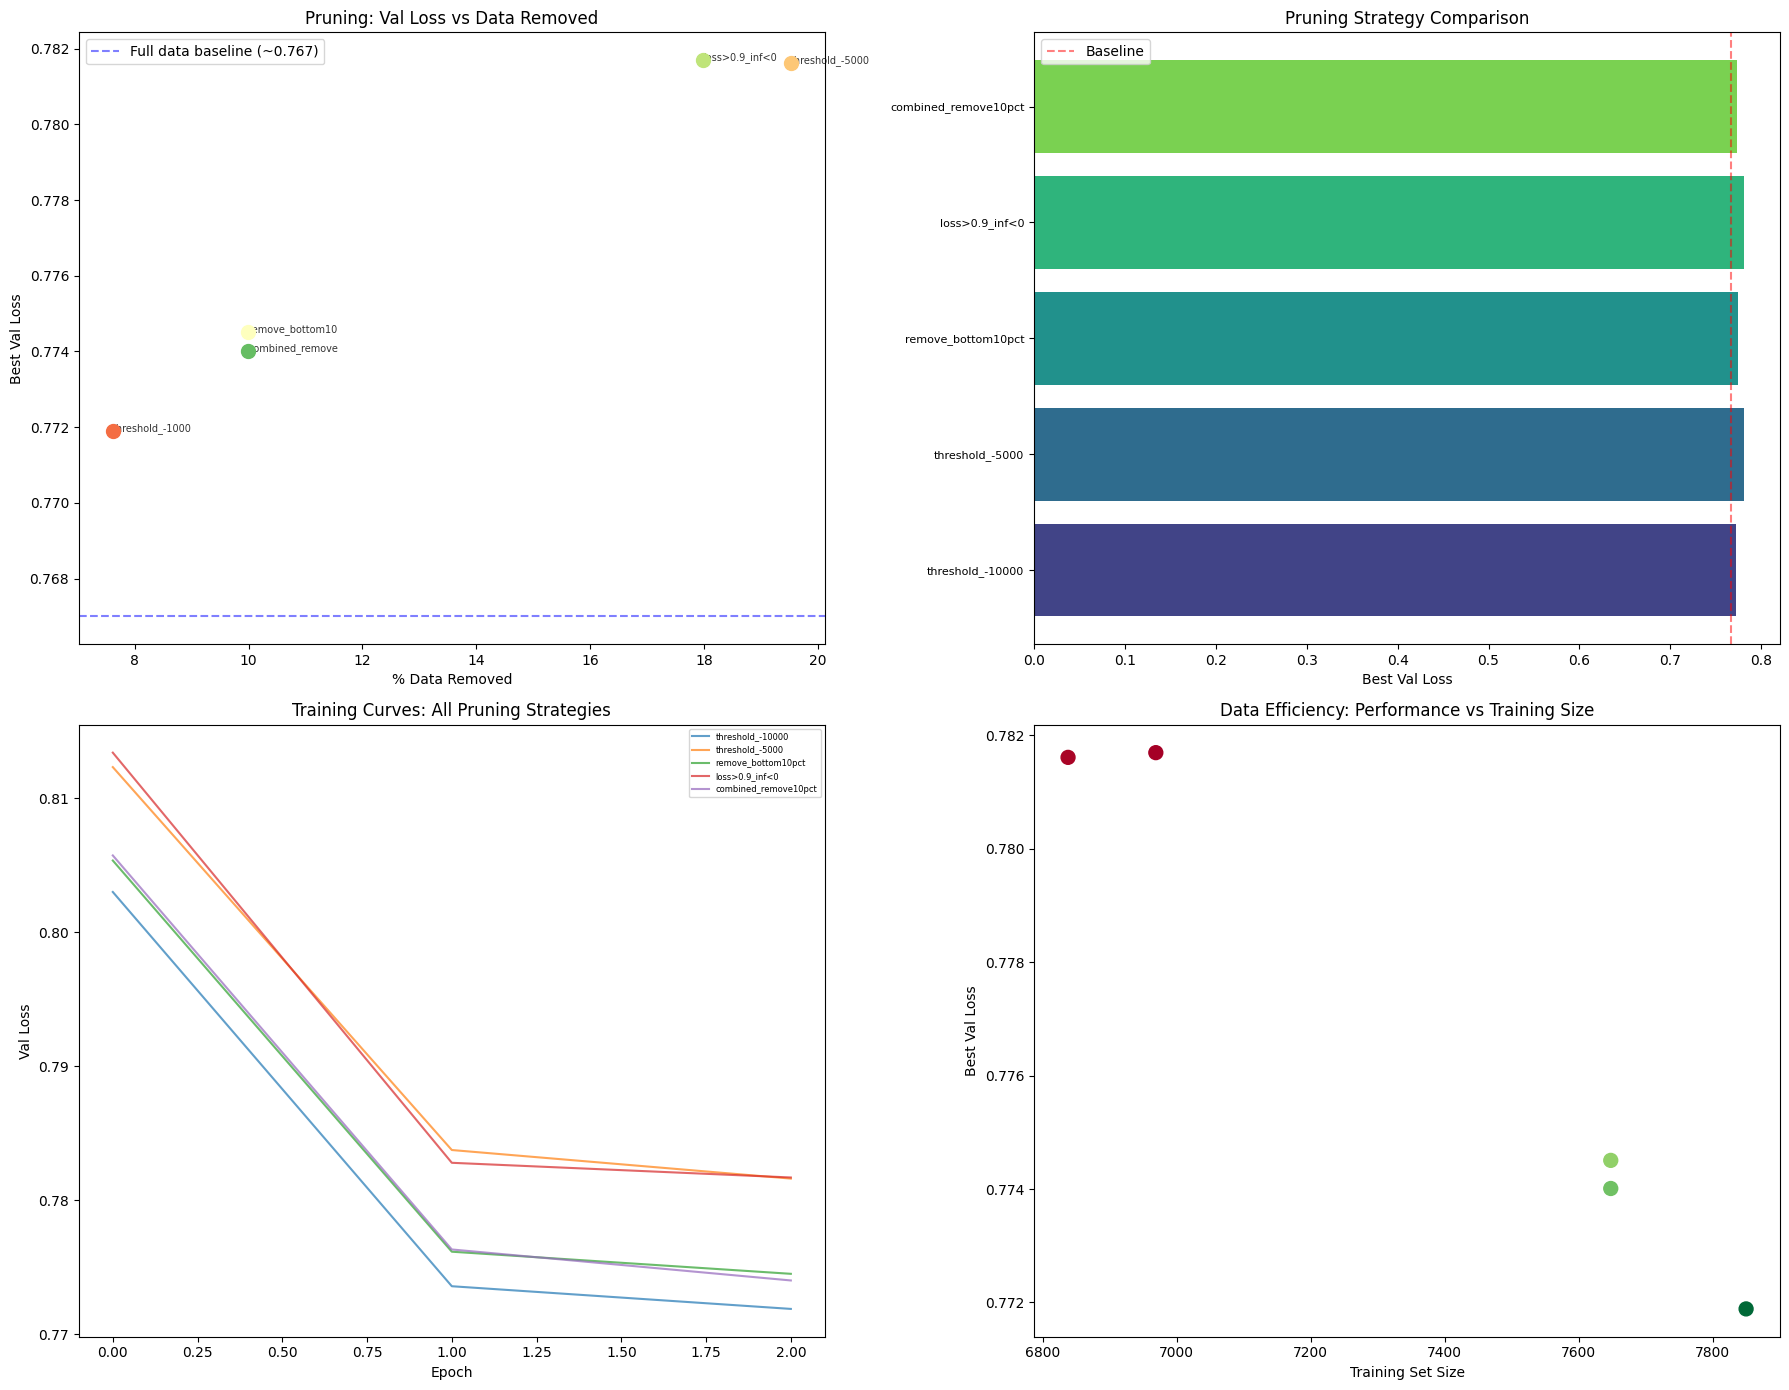

In [13]:
# ===== 1.4 Pruning Visualization =====
fig, axes = plt.subplots(2, 2, figsize=(18, 14))

# 1. Val loss vs removed percentage
ax = axes[0, 0]
colors = plt.cm.RdYlGn(np.linspace(0.2, 0.8, len(pruning_results)))
for i, (name, r) in enumerate(pruning_results.items()):
    removed_pct = (1 - r["train_size"]/len(ds_train)) * 100
    ax.scatter(removed_pct, r["val_loss_best"], c=[colors[i]], s=100, zorder=5)
    ax.annotate(name[:15], (removed_pct, r["val_loss_best"]), fontsize=7, alpha=0.8)
# Baseline (full dataset) — approximate from Part 1
ax.axhline(y=0.767, color='blue', linestyle='--', alpha=0.5, label='Full data baseline (~0.767)')
ax.set_xlabel("% Data Removed")
ax.set_ylabel("Best Val Loss")
ax.set_title("Pruning: Val Loss vs Data Removed")
ax.legend()

# 2. Bar chart: best val loss for each strategy
ax = axes[0, 1]
names = list(pruning_results.keys())
best_losses = [pruning_results[n]["val_loss_best"] for n in names]
bars = ax.barh(range(len(names)), best_losses, color=plt.cm.viridis(np.linspace(0.2, 0.8, len(names))))
ax.set_yticks(range(len(names)))
ax.set_yticklabels([n[:30] for n in names], fontsize=8)
ax.axvline(x=0.767, color='red', linestyle='--', alpha=0.5, label='Baseline')
ax.set_xlabel("Best Val Loss")
ax.set_title("Pruning Strategy Comparison")
ax.legend()

# 3. Training curves
ax = axes[1, 0]
for name, r in pruning_results.items():
    if r["val_losses"]:
        ax.plot(r["val_losses"], label=name[:20], alpha=0.7)
ax.set_xlabel("Epoch")
ax.set_ylabel("Val Loss")
ax.set_title("Training Curves: All Pruning Strategies")
ax.legend(fontsize=6, loc='upper right')

# 4. Data efficiency curve
ax = axes[1, 1]
sizes = [(1 - r["train_size"]/len(ds_train)) for _, r in pruning_results.items()]
losses = [r["val_loss_best"] for _, r in pruning_results.items()]
ax.scatter([len(ds_train) - int(s * len(ds_train)) for s in sizes], losses, c=losses, cmap='RdYlGn_r', s=100)
ax.set_xlabel("Training Set Size")
ax.set_ylabel("Best Val Loss")
ax.set_title("Data Efficiency: Performance vs Training Size")

plt.tight_layout()
plt.savefig(ROOT + "/outputs/experiments_p2/pruning_comparison.png", dpi=150)
plt.show()

---
## 2. 📚 Influence-based Curriculum Learning

**Goal**: Design curriculum learning strategies where training order is determined by influence scores.
This tests whether the ORDER of training matters based on influence.

### Strategies:
1. **influence_asc**: Low influence → High influence (start with less helpful)
2. **influence_desc**: High influence → Low influence (start with most helpful)
3. **abs_influence_asc**: Low |influence| → High |influence| (start with neutral)
4. **abs_influence_desc**: High |influence| → Low |influence| (start with extreme)
5. **sandwich_influence**: High → Low → High (sandwich)
6. **hybrid_influence_diff**: Combine influence with text difficulty
7. **anti_curriculum**: Maximize influence fluctuation (alternating)

**Comparison**: All strategies are compared against the Part 1 results (random, easy_to_hard, hard_to_easy, baby_step, mixed_curriculum).

In [14]:
# ===== 2.1 Define Influence-based Curriculum Strategies =====

def add_influence_features(example, idx):
    """Add influence and derived features to each example"""
    text = example["text"]
    example["difficulty"] = len(text) + 10 * text.count("\n") + 5 * text.count("=") + 5 * text.count("→")
    example["influence_score"] = float(influences[idx])
    example["abs_influence"] = float(abs(influences[idx]))
    example["proof_length"] = len(example.get("formal_ground_truth", ""))
    if train_losses is not None:
        example["train_loss"] = float(train_losses[idx])
    return example

# Add influence features to training set
ds_train_enriched = ds_train.map(
    lambda ex, idx: add_influence_features(ex, idx),
    with_indices=True, desc="Enrich with influence"
)
print(f"Enriched dataset columns: {ds_train_enriched.column_names}")

Enrich with influence:   0%|          | 0/8497 [00:00<?, ? examples/s]

Enriched dataset columns: ['uuid', 'problem', 'question_type', 'answer', 'author', 'formal_statement', 'formal_ground_truth', 'ground_truth_type', 'formal_proof', 'rl_data', 'source', 'problem_type', 'exam', 'text', 'difficulty', 'influence_score', 'abs_influence', 'proof_length', 'train_loss']


In [15]:
def get_influence_curriculum(strategy, seed=42):
    """Return reordered dataset based on influence-based curriculum strategy"""
    ds = ds_train_enriched

    if strategy == "influence_asc":
        # Low influence first, high influence last
        return ds.sort("influence_score")

    elif strategy == "influence_desc":
        # High influence first, low influence last
        return ds.sort("influence_score", reverse=True)

    elif strategy == "abs_influence_asc":
        # Small |influence| first (neutral samples), extreme last
        return ds.sort("abs_influence")

    elif strategy == "abs_influence_desc":
        # Extreme |influence| first (most helpful or harmful), neutral last
        return ds.sort("abs_influence", reverse=True)

    elif strategy == "sandwich_influence":
        # High influence → Low influence → High influence
        sorted_ds = ds.sort("influence_score", reverse=True)
        n = len(sorted_ds)
        third = n // 3
        # Take first third (high), then last third (low), then middle third (mid)
        indices = (
            list(range(third)) +                          # Top third (high influence)
            list(range(2*third, n)) +                     # Bottom third (low influence)
            list(range(third, 2*third))                   # Middle third
        )
        return sorted_ds.select(indices)

    elif strategy == "hybrid_influence_diff":
        # Combine influence and difficulty into a single score
        # Normalize both to [0, 1]
        inf_scores = np.array([ds[i]["influence_score"] for i in range(len(ds))])
        diff_scores = np.array([ds[i]["difficulty"] for i in range(len(ds))])

        # Z-score normalization
        inf_norm = (inf_scores - inf_scores.mean()) / (inf_scores.std() + 1e-8)
        diff_norm = (diff_scores - diff_scores.mean()) / (diff_scores.std() + 1e-8)

        # Composite: influence-weighted difficulty (positive influence = easier)
        composite = diff_norm - 0.5 * inf_norm

        sorted_indices = np.argsort(composite)
        return ds.select(sorted_indices)

    elif strategy == "anti_curriculum":
        # Maximize fluctuation: interleave highest and lowest influence
        sorted_ds = ds.sort("influence_score", reverse=True)
        n = len(sorted_ds)
        # Interleave: highest, lowest, 2nd highest, 2nd lowest, ...
        high_indices = list(range(n // 2))
        low_indices = list(range(n - 1, n // 2 - 1, -1))
        indices = []
        for h, l in zip(high_indices, low_indices):
            indices.extend([h, l])
        if len(high_indices) > len(low_indices):
            indices.append(high_indices[-1])
        return sorted_ds.select(indices)

    elif strategy == "importance_sampling":
        # Up-sample high influence, down-sample low influence
        # Create weighted dataset by sampling with replacement
        inf_scores = np.array([ds[i]["influence_score"] for i in range(len(ds))])
        # Shift to positive range
        weights = inf_scores - inf_scores.min() + 1e-6
        weights = weights / weights.sum()
        # Sample indices (oversample high influence)
        n_sample = len(ds)
        sampled_indices = np.random.choice(len(ds), size=n_sample, replace=True, p=weights)
        # Remove duplicates while preserving order
        _, unique_idx = np.unique(sampled_indices, return_index=True)
        unique_idx = np.sort(unique_idx)
        selected = sampled_indices[unique_idx]
        return ds.select(selected)

    else:
        raise ValueError(f"Unknown strategy: {strategy}")


# ===== Define all curriculum experiments =====
curriculum_strategies = [
    "influence_asc",          # Low → High influence
    "influence_desc",         # High → Low influence
    "abs_influence_asc",      # Small |influence| → Large
    "abs_influence_desc",     # Large |influence| → Small
    "sandwich_influence",    # High → Low → High
    "hybrid_influence_diff", # Influence + Difficulty hybrid
    "anti_curriculum",       # Maximum fluctuation
    "importance_sampling",   # Weighted sampling by influence
]

print("=== Influence-based Curriculum Strategies ===")
for s in curriculum_strategies:
    ds_ord = get_influence_curriculum(s)
    first_inf = ds_ord[0]["influence_score"]
    last_inf = ds_ord[-1]["influence_score"]
    print(f"  {s:30s} | size={len(ds_ord):5d} | first_inf={first_inf:10.2f} | last_inf={last_inf:10.2f}")

=== Influence-based Curriculum Strategies ===
  influence_asc                  | size= 8497 | first_inf= -57908.62 | last_inf=  11216.17
  influence_desc                 | size= 8497 | first_inf=  11216.17 | last_inf= -57908.62
  abs_influence_asc              | size= 8497 | first_inf=     -0.33 | last_inf= -57908.62
  abs_influence_desc             | size= 8497 | first_inf= -57908.62 | last_inf=     -0.33
  sandwich_influence             | size= 8497 | first_inf=  11216.17 | last_inf=  -2769.63
  hybrid_influence_diff          | size= 8497 | first_inf=  11216.17 | last_inf=  -1368.98
  anti_curriculum                | size= 8496 | first_inf=  11216.17 | last_inf=  -1141.80
  importance_sampling            | size= 5368 | first_inf=  -4031.94 | last_inf=   2282.75


In [16]:
# ===== 2.2 Run Influence-based Curriculum Experiments =====
curriculum_results = {}

for strategy in curriculum_strategies:
    print(f"\n{'='*60}")
    print(f"📚 Curriculum: {strategy}")

    ds_ord = get_influence_curriculum(strategy)

    result = train_and_evaluate(ds_ord, f"curriculum_{strategy}")
    curriculum_results[strategy] = result

    print(f"  ✅ Best val loss: {result['val_loss_best']:.4f}, Final: {result['val_loss_final']:.4f}")

# Save summary
df_curr = pd.DataFrame([{
    "name": name,
    "train_size": r["train_size"],
    "val_loss_best": r["val_loss_best"],
    "val_loss_final": r["val_loss_final"],
} for name, r in curriculum_results.items()])
df_curr.to_csv(ROOT + "/outputs/experiments_p2/curriculum_influence_results.csv", index=False)
print("\n=== Influence-based Curriculum Results ===")
print(df_curr.sort_values("val_loss_best").to_string())


📚 Curriculum: influence_asc


Loading weights:   0%|          | 0/290 [00:00<?, ?it/s]

Adding EOS to train dataset:   0%|          | 0/8497 [00:00<?, ? examples/s]

Tokenizing train dataset:   0%|          | 0/8497 [00:00<?, ? examples/s]

The tokenizer has new PAD/BOS/EOS tokens that differ from the model config and generation config. The model config and generation config were aligned accordingly, being updated with the tokenizer's values. Updated tokens: {'bos_token_id': None, 'pad_token_id': 151643}.


...

Adding EOS to train dataset:   0%|          | 0/5368 [00:00<?, ? examples/s]

Tokenizing train dataset:   0%|          | 0/5368 [00:00<?, ? examples/s]

The tokenizer has new PAD/BOS/EOS tokens that differ from the model config and generation config. The model config and generation config were aligned accordingly, being updated with the tokenizer's values. Updated tokens: {'bos_token_id': None, 'pad_token_id': 151643}.


Epoch,Training Loss,Validation Loss
1,0.823998,0.826521
2,0.814514,0.796215
3,0.827843,0.793519


  ✅ Best val loss: 0.7935, Final: 0.7935

=== Influence-based Curriculum Results ===
                    name  train_size  val_loss_best  val_loss_final
2      abs_influence_asc        8497       0.766497        0.766497
3     abs_influence_desc        8497       0.766499        0.766499
6        anti_curriculum        8496       0.766620        0.766620
0          influence_asc        8497       0.766763        0.766763
5  hybrid_influence_diff        8497       0.766804        0.766804
4     sandwich_influence        8497       0.766817        0.766817
1         influence_desc        8497       0.766895        0.766895
7    importance_sampling        5368       0.793519        0.793519


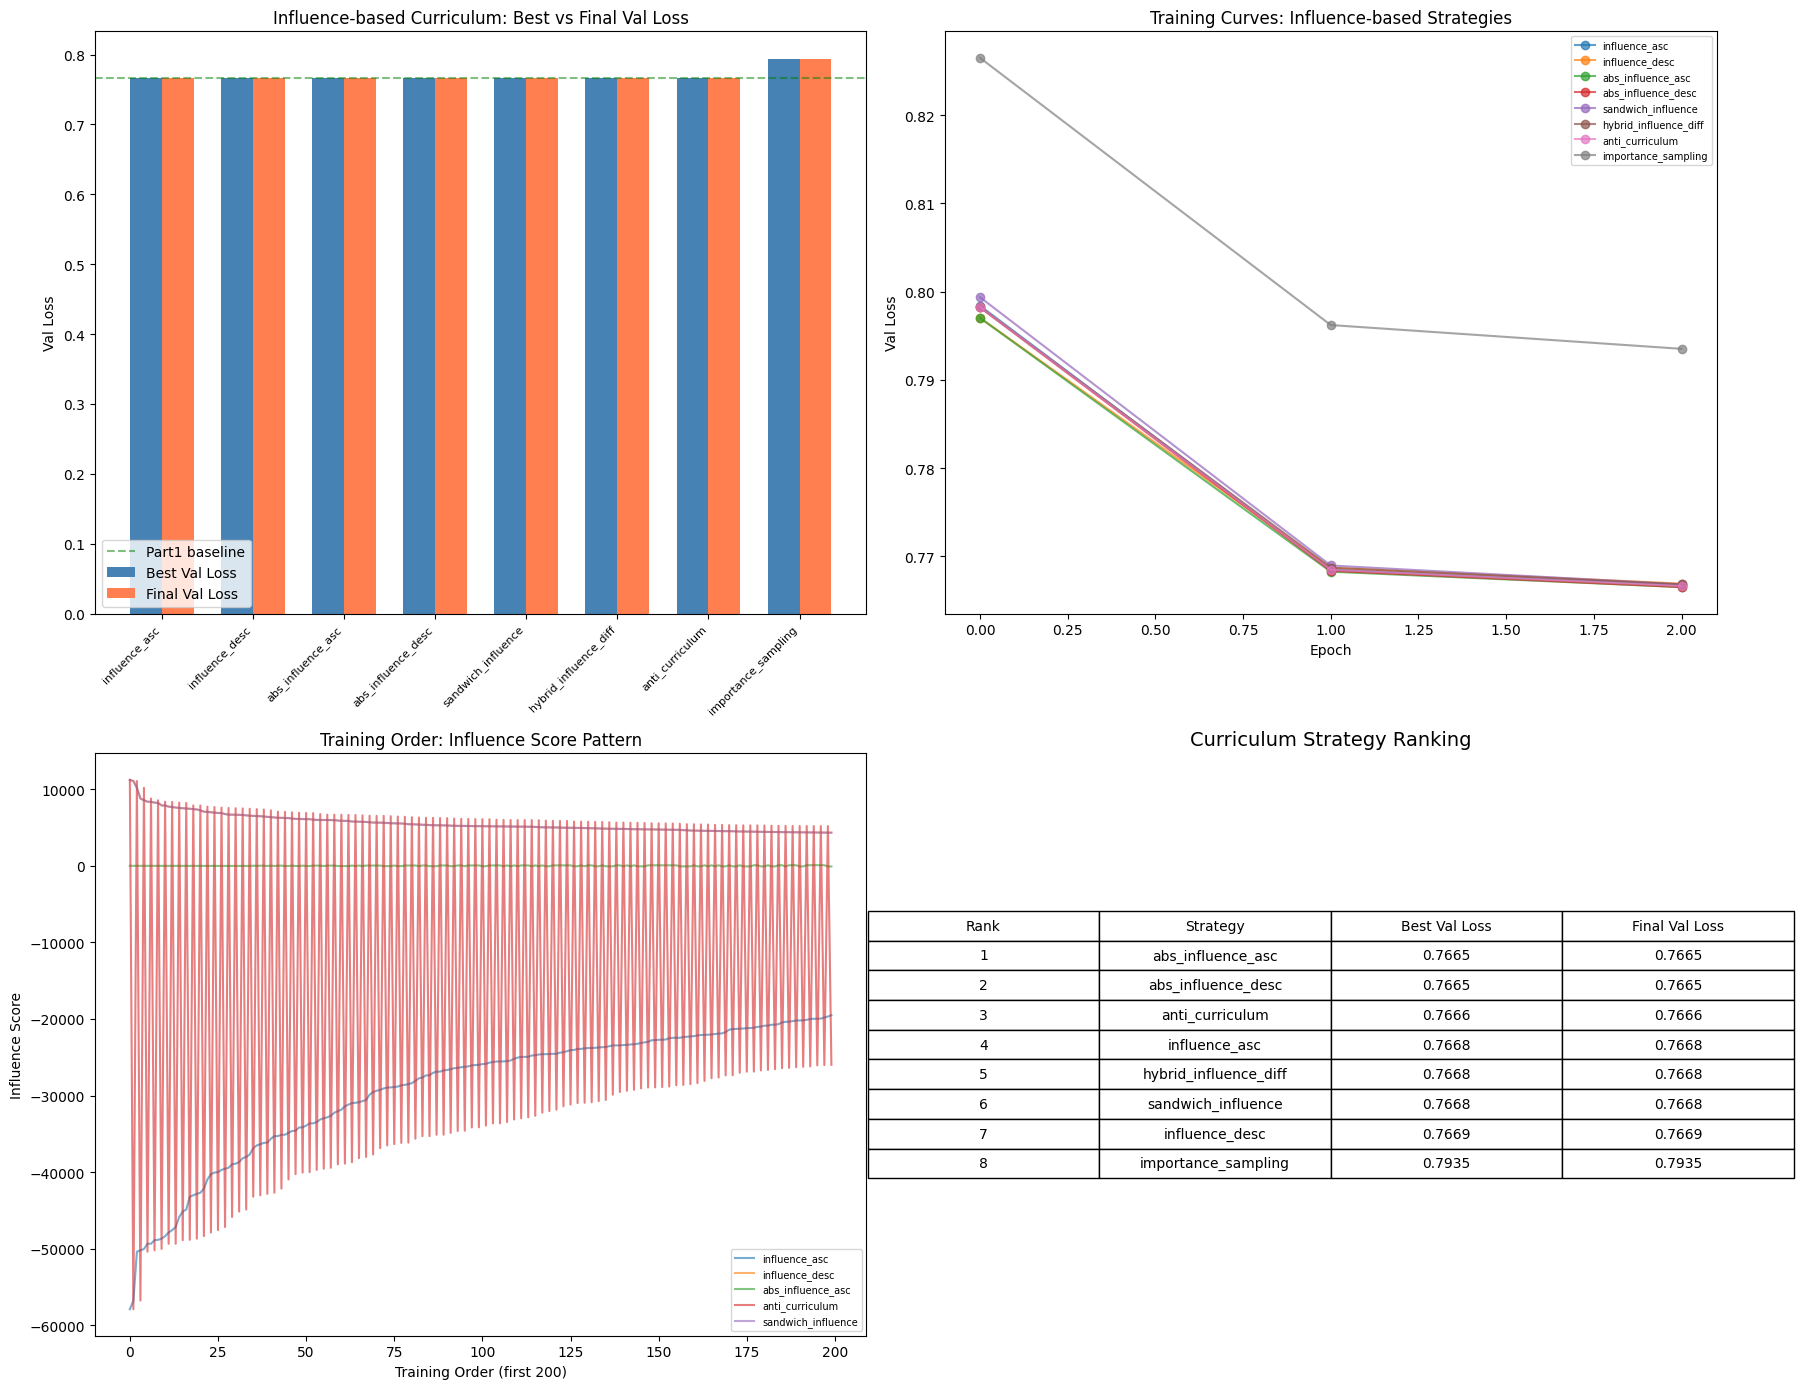

In [17]:
# ===== 2.3 Curriculum Visualization =====
fig, axes = plt.subplots(2, 2, figsize=(18, 14))

# 1. Bar comparison
ax = axes[0, 0]
names = list(curriculum_results.keys())
best_losses = [curriculum_results[n]["val_loss_best"] for n in names]
final_losses = [curriculum_results[n]["val_loss_final"] for n in names]
x = np.arange(len(names))
width = 0.35
bars1 = ax.bar(x - width/2, best_losses, width, label='Best Val Loss', color='steelblue')
bars2 = ax.bar(x + width/2, final_losses, width, label='Final Val Loss', color='coral')
ax.set_xticks(x)
ax.set_xticklabels(names, rotation=45, ha='right', fontsize=8)
ax.axhline(y=0.767, color='green', linestyle='--', alpha=0.5, label='Part1 baseline')
ax.set_ylabel("Val Loss")
ax.set_title("Influence-based Curriculum: Best vs Final Val Loss")
ax.legend()

# 2. Training curves comparison
ax = axes[0, 1]
for name, r in curriculum_results.items():
    if r["val_losses"]:
        ax.plot(r["val_losses"], marker='o', label=name, alpha=0.7)
ax.set_xlabel("Epoch")
ax.set_ylabel("Val Loss")
ax.set_title("Training Curves: Influence-based Strategies")
ax.legend(fontsize=7)

# 3. Ordering visualization (first 200 samples)
ax = axes[1, 0]
sample_strategies = ["influence_asc", "influence_desc", "abs_influence_asc", "anti_curriculum", "sandwich_influence"]
for s in sample_strategies:
    ds_ord = get_influence_curriculum(s)
    first_200_inf = [ds_ord[i]["influence_score"] for i in range(min(200, len(ds_ord)))]
    ax.plot(first_200_inf, alpha=0.6, label=s[:20])
ax.set_xlabel("Training Order (first 200)")
ax.set_ylabel("Influence Score")
ax.set_title("Training Order: Influence Score Pattern")
ax.legend(fontsize=7)

# 4. Ranking table
ax = axes[1, 1]
ax.axis('off')
df_sorted = df_curr.sort_values("val_loss_best")
table_data = [[i+1, row["name"], f"{row['val_loss_best']:.4f}", f"{row['val_loss_final']:.4f}"]
              for i, (_, row) in enumerate(df_sorted.iterrows())]
table = ax.table(
    cellText=table_data,
    colLabels=["Rank", "Strategy", "Best Val Loss", "Final Val Loss"],
    loc='center', cellLoc='center'
)
table.auto_set_font_size(False)
table.set_fontsize(10)
table.scale(1.2, 1.5)
ax.set_title("Curriculum Strategy Ranking", fontsize=14)

plt.tight_layout()
plt.savefig(ROOT + "/outputs/experiments_p2/curriculum_influence_comparison.png", dpi=150)
plt.show()

---
## 3. 📐 Multi-Proof Impact Analysis

**Problem**: Only 6 theorems have ≥2 proofs in training set — too few for statistical analysis.

**Approach**: Design experiments that maximize insights from limited multi-proof data, plus
expand analysis to val/test sets and use data augmentation techniques.

### Experiments:
1. **Detailed case study**: For each multi-proof theorem, analyze individual proof characteristics
2. **Cross-set analysis**: Check multi-proof theorems in val/test sets
3. **Proof selection ablation**: Train with only best/worst proof per theorem
4. **Proof concatenation**: Combine multiple proofs as one training example
5. **Influence consistency**: Do high-influence proofs generalize better?
6. **Proof diversity metrics**: Quantify and correlate diversity with model performance

In [18]:
# ===== 3.1 Multi-Proof Discovery Across All Splits =====

def find_multi_proofs(dataset, name="dataset"):
    """Find theorems with multiple proofs"""
    stmt_to_idx = defaultdict(list)
    for i in range(len(dataset)):
        stmt = dataset[i]["formal_statement"].strip()
        stmt_to_idx[stmt].append(i)
    multi = {k: v for k, v in stmt_to_idx.items() if len(v) >= 2}
    print(f"\n{name}: {len(dataset)} total, {len(multi)} theorems with ≥2 proofs")
    return multi

multi_train = find_multi_proofs(ds_train, "Train")
multi_val = find_multi_proofs(ds_val, "Val")
multi_test = find_multi_proofs(ds_test, "Test")

# Also check cross-set: same theorem appearing in train AND val/test
train_stmts = set(ds_train[i]["formal_statement"].strip() for i in range(len(ds_train)))
val_stmts = set(ds_val[i]["formal_statement"].strip() for i in range(len(ds_val)))
test_stmts = set(ds_test[i]["formal_statement"].strip() for i in range(len(ds_test)))

cross_val = train_stmts & val_stmts
cross_test = train_stmts & test_stmts
print(f"\nCross-set overlap:")
print(f"  Train ∩ Val: {len(cross_val)} theorems")
print(f"  Train ∩ Test: {len(cross_test)} theorems")


Train: 8497 total, 6 theorems with ≥2 proofs

Val: 472 total, 0 theorems with ≥2 proofs

Test: 473 total, 0 theorems with ≥2 proofs

Cross-set overlap:
  Train ∩ Val: 1 theorems
  Train ∩ Test: 3 theorems


In [19]:
# ===== 3.2 Detailed Multi-Proof Case Study =====

def analyze_multi_proof(stmt, idxs, dataset):
    """Detailed analysis of a theorem with multiple proofs"""
    records = []
    for idx in idxs:
        ex = dataset[idx]
        proof = ex.get("formal_ground_truth", "")
        inf = float(influences[idx]) if idx < len(influences) else None
        loss = float(train_losses[idx]) if (train_losses is not None and idx < len(train_losses)) else None
        records.append({
            "idx": idx,
            "proof_length": len(proof),
            "n_lines": proof.count("\n"),
            "n_tactics": proof.count("by") + proof.count("⟨") + proof.count("apply"),
            "influence": inf,
            "train_loss": loss,
        })
    return records

all_multi_analysis = []

for stmt, idxs in multi_train.items():
    analysis = analyze_multi_proof(stmt, idxs, ds_train)
    df_case = pd.DataFrame(analysis)

    # Compute diversity metrics
    proof_lengths = df_case["proof_length"].values
    inf_values = df_case["influence"].dropna().values

    summary = {
        "theorem_preview": stmt[:80] + "..." if len(stmt) > 80 else stmt,
        "n_proofs": len(idxs),
        "length_range": f"{proof_lengths.min()}-{proof_lengths.max()}",
        "length_cv": proof_lengths.std() / (proof_lengths.mean() + 1e-8),  # coefficient of variation
        "influence_range": f"{inf_values.min():.1f} ~ {inf_values.max():.1f}" if len(inf_values) > 0 else "N/A",
        "influence_std": inf_values.std() if len(inf_values) > 1 else 0,
        "influence_gap": inf_values.max() - inf_values.min() if len(inf_values) > 1 else 0,
        "best_proof_idx": idxs[df_case["influence"].idxmax()] if "influence" in df_case and df_case["influence"].notna().any() else None,
        "worst_proof_idx": idxs[df_case["influence"].idxmin()] if "influence" in df_case and df_case["influence"].notna().any() else None,
    }
    all_multi_analysis.append(summary)

    print(f"\n{'='*60}")
    print(f"Theorem: {stmt[:100]}...")
    print(f"  Proofs: {len(idxs)}, Indices: {idxs}")
    print(df_case.to_string(index=False))

df_multi = pd.DataFrame(all_multi_analysis)
print(f"\n\n=== Multi-Proof Summary ({len(df_multi)} theorems) ===")
print(df_multi.to_string())
df_multi.to_csv(ROOT + "/outputs/experiments_p2/multi_proof_analysis.csv", index=False)


Theorem: import Mathlib
open Real Set
open scoped BigOperators
theorem algebra_9245 : range (fun (x : {x : ℝ ...
  Proofs: 2, Indices: [223, 3454]
 idx  proof_length  n_lines  n_tactics    influence  train_loss
 223          1613       42         17 -6422.440918    0.892758
3454          1634       43         17 -6545.631348    0.901221

Theorem: import Mathlib
open Real Set
open scoped BigOperators
theorem algebra_16876 : IsLeast {y : ℝ | ∃ x, ...
  Proofs: 2, Indices: [253, 5817]
 idx  proof_length  n_lines  n_tactics     influence  train_loss
 253           346       11          6  -9120.617188    0.833659
5817           347       12          6 -12855.271484    0.827683

Theorem: import Mathlib.Tactic.Linarith
import Mathlib.Algebra.Polynomial.Coeff
import Mathlib.Data.Nat.Choos...
  Proofs: 2, Indices: [1241, 5576]
 idx  proof_length  n_lines  n_tactics    influence  train_loss
1241          1935       55         11  1106.087891    0.900715
5576          1700       41         10 -

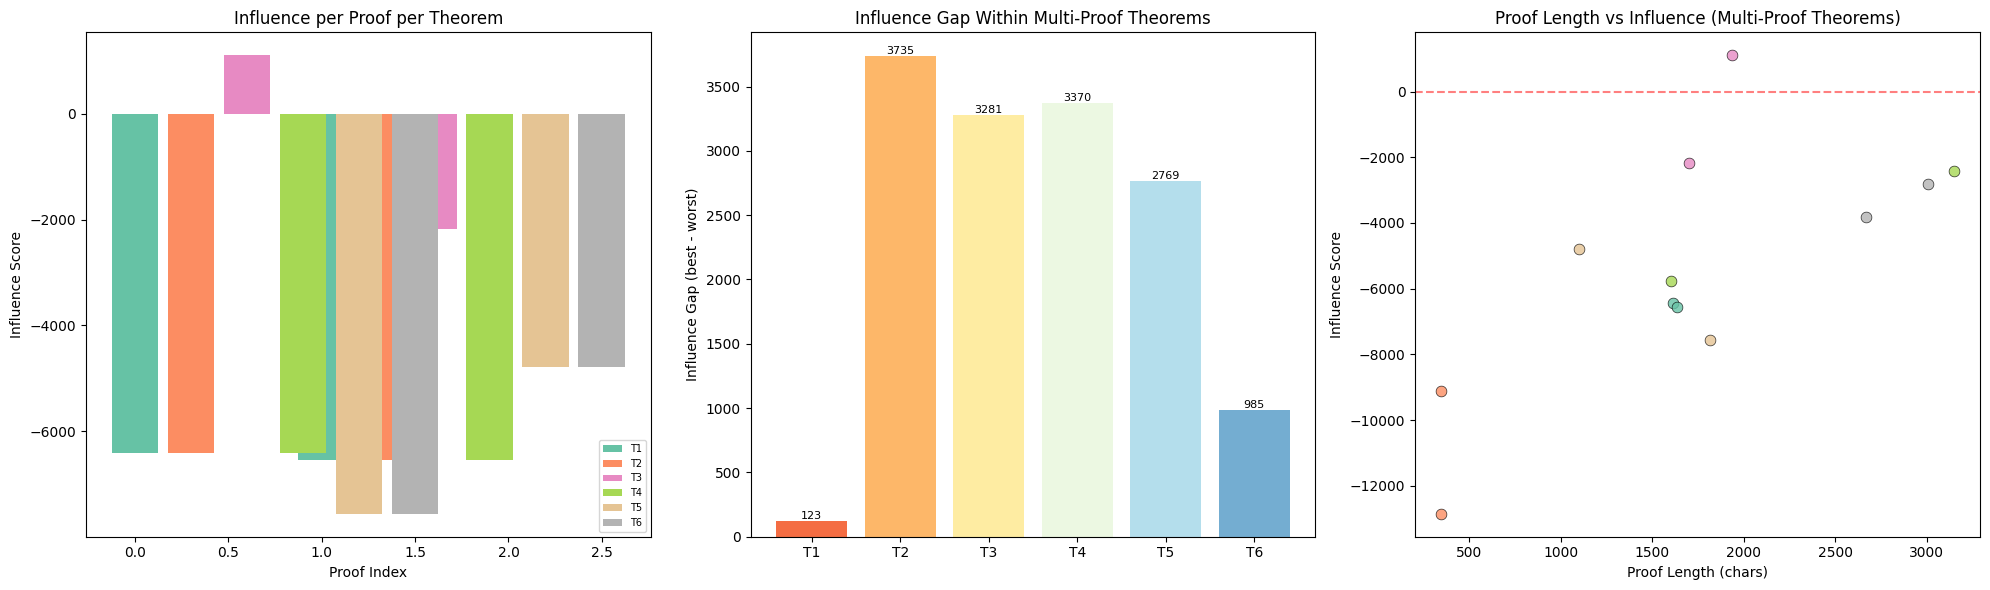

In [21]:
# ===== 3.3 Multi-Proof Visualization =====

fig, axes = plt.subplots(1, 3, figsize=(20, 6))

# 1. Influence comparison for multi-proof theorems
ax = axes[0]
colors_mp = plt.cm.Set2(np.linspace(0, 1, max(len(df_multi), df_multi["n_proofs"].max(), 3)))
for i, row in df_multi.iterrows():
    stmt_short = row["theorem_preview"][:25]
    stmt_to_find = None
    for stmt, idxs in multi_train.items():
        if stmt[:25] == stmt_short:
            stmt_to_find = stmt
            break
    if stmt_to_find is None:
        continue
    idxs = multi_train[stmt_to_find]
    infs = [influences[idx] for idx in idxs if idx < len(influences)]
    x_pos = np.arange(len(infs)) + i * 0.3
    ax.bar(x_pos, infs, width=0.25, label=f'T{i+1}', color=colors_mp[i])
ax.set_xlabel("Proof Index")
ax.set_ylabel("Influence Score")
ax.set_title("Influence per Proof per Theorem")
ax.legend(fontsize=7)

# 2. Influence gap between best and worst proof
ax = axes[1]
gaps = df_multi["influence_gap"].values
names_mp = [f"T{i+1}" for i in range(len(gaps))]
ax.bar(names_mp, gaps, color=plt.cm.RdYlBu(np.linspace(0.2, 0.8, len(gaps))))
ax.set_ylabel("Influence Gap (best - worst)")
ax.set_title("Influence Gap Within Multi-Proof Theorems")
for j, g in enumerate(gaps):
    ax.text(j, g, f"{g:.0f}", ha='center', va='bottom', fontsize=8)

# 3. Length vs Influence scatter for multi-proof samples
ax = axes[2]
for i, (stmt, idxs) in enumerate(multi_train.items()):
    for idx in idxs:
        if idx < len(influences):
            ax.scatter(
                len(ds_train[idx]["formal_ground_truth"]),
                influences[idx],
                c=[colors_mp[i]], s=60, alpha=0.8, edgecolors='black', linewidth=0.5
            )
ax.axhline(y=0, color='red', linestyle='--', alpha=0.5)
ax.set_xlabel("Proof Length (chars)")
ax.set_ylabel("Influence Score")
ax.set_title("Proof Length vs Influence (Multi-Proof Theorems)")

plt.tight_layout()
plt.savefig(ROOT + "/outputs/experiments_p2/multi_proof_visualization.png", dpi=150)
plt.show()

In [23]:
# ===== 3.4 Proof Characteristics by Influence Tier =====
import scipy.stats as stats

inf_q33 = np.percentile(influences, 33)
inf_q66 = np.percentile(influences, 66)

proof_lens = np.array([len(ds_train[i]["formal_ground_truth"]) for i in range(len(ds_train))])
proof_lines = np.array([ds_train[i]["formal_ground_truth"].count("\n") for i in range(len(ds_train))])
tactic_counts = np.array([
    ds_train[i]["formal_ground_truth"].count("by ") +
    ds_train[i]["formal_ground_truth"].count("apply ") +
    ds_train[i]["formal_ground_truth"].count("⟨") +
    ds_train[i]["formal_ground_truth"].count("rw ") +
    ds_train[i]["formal_ground_truth"].count("simp ")
    for i in range(len(ds_train))
])
stmt_lens = np.array([len(ds_train[i]["formal_statement"]) for i in range(len(ds_train))])

groups = {
    "Low influence (harmful)": influences < inf_q33,
    "Mid influence (neutral)": (influences >= inf_q33) & (influences < inf_q66),
    "High influence (helpful)": influences >= inf_q66,
}

print(f"Influence thresholds: P33={inf_q33:.1f}, P66={inf_q66:.1f}")
print(f"\n{'Tier':30s} | {'Count':>5} | {'Avg Len':>8} | {'Avg Lines':>9} | {'Avg Tactics':>10} | {'Avg Inf':>10}")
print("-" * 90)
tier_data = {}
for name, mask in groups.items():
    row = {
        "name": name,
        "count": mask.sum(),
        "avg_len": proof_lens[mask].mean(),
        "avg_lines": proof_lines[mask].mean(),
        "avg_tactics": tactic_counts[mask].mean(),
        "avg_inf": influences[mask].mean(),
    }
    tier_data[name] = row
    print(f"{name:30s} | {mask.sum():5d} | {proof_lens[mask].mean():8.1f} | "
          f"{proof_lines[mask].mean():9.1f} | {tactic_counts[mask].mean():10.1f} | "
          f"{influences[mask].mean():10.1f}")

df_tiers = pd.DataFrame(tier_data).T
df_tiers.to_csv(ROOT + "/outputs/experiments_p2/proof_tier_analysis.csv", index=False)

Influence thresholds: P33=-2812.0, P66=76.1

Tier                           | Count |  Avg Len | Avg Lines | Avg Tactics |    Avg Inf
------------------------------------------------------------------------------------------
Low influence (harmful)        |  2804 |   1456.7 |      38.9 |       15.7 |    -8351.0
Mid influence (neutral)        |  2804 |   3633.2 |      94.3 |       39.1 |    -1242.9
High influence (helpful)       |  2889 |   4120.8 |     105.7 |       38.8 |     1880.2


=== Correlation with Influence Score ===
Feature                   |  Pearson r |      p-value |  Spearman ρ |      p-value
--------------------------------------------------------------------------------
Proof Length              |     0.2876 |    1.64e-161 |      0.4737 |     0.00e+00
Proof Lines               |     0.2731 |    3.13e-145 |      0.4490 |     0.00e+00
Tactic Count              |     0.2332 |    2.44e-105 |      0.3603 |    8.06e-259
Statement Length          |     0.1433 |     3.13e-40 |      0.3248 |    6.41e-208
Length / Lines ratio      |     0.1523 |     2.74e-45 |      0.1244 |     1.12e-30
Tactics per Line          |     0.1368 |     9.11e-37 |      0.0941 |     3.70e-18


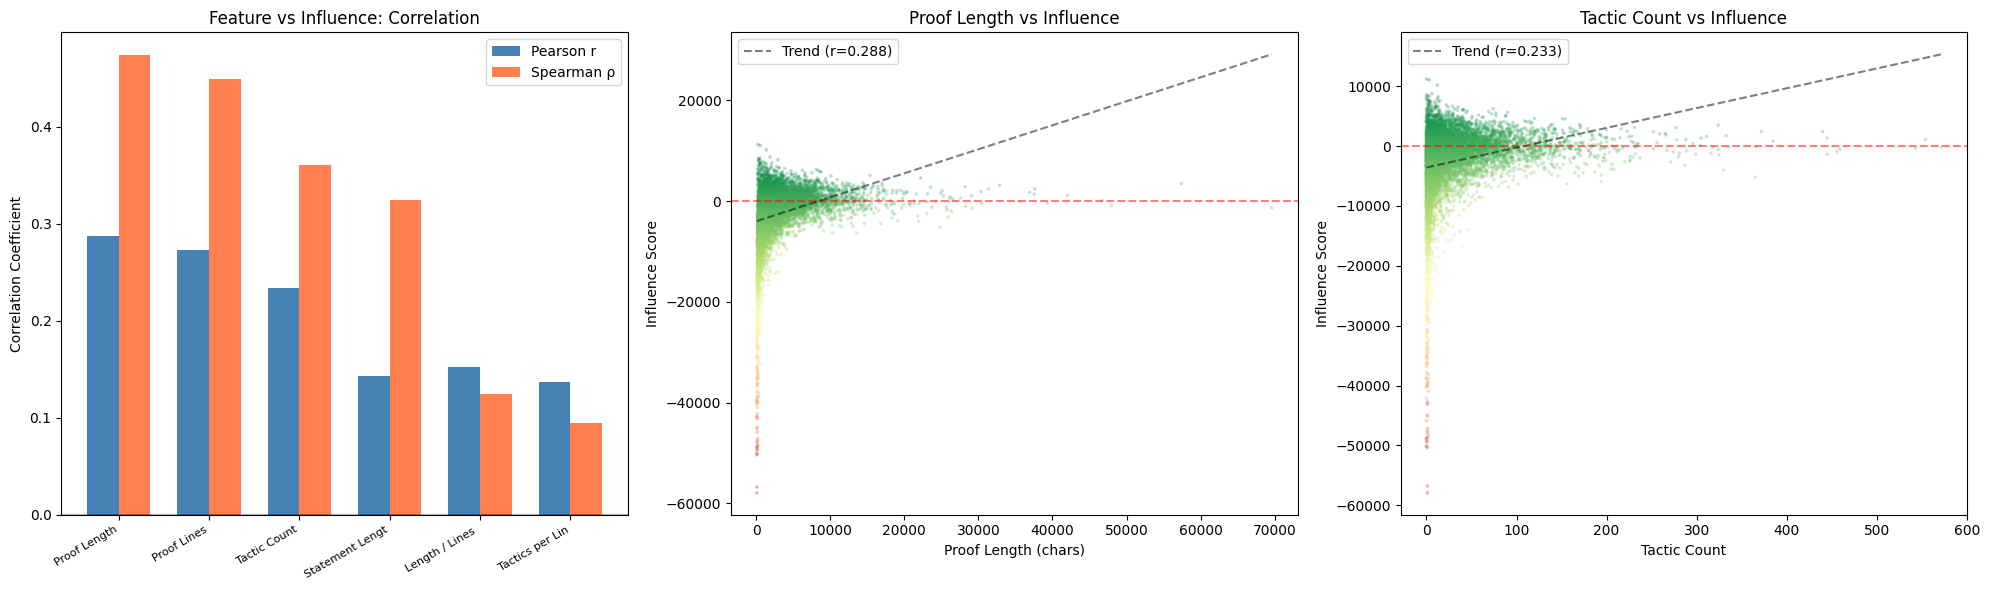

In [25]:
# ===== 3.5 Correlation Analysis: Features vs Influence =====

features = {
    "Proof Length": proof_lens,
    "Proof Lines": proof_lines,
    "Tactic Count": tactic_counts,
    "Statement Length": stmt_lens,
    "Length / Lines ratio": proof_lens / (proof_lines + 1),
    "Tactics per Line": tactic_counts / (proof_lines + 1),
}

print("=== Correlation with Influence Score ===")
print(f"{'Feature':25s} | {'Pearson r':>10} | {'p-value':>12} | {'Spearman ρ':>11} | {'p-value':>12}")
print("-" * 80)

corr_results = []
for fname, fvals in features.items():
    r, p = stats.pearsonr(fvals, influences)
    rho, p_s = stats.spearmanr(fvals, influences)
    corr_results.append({"feature": fname, "pearson_r": r, "pearson_p": p, "spearman_rho": rho, "spearman_p": p_s})
    print(f"{fname:25s} | {r:10.4f} | {p:12.2e} | {rho:11.4f} | {p_s:12.2e}")

df_corr = pd.DataFrame(corr_results)
df_corr.to_csv(ROOT + "/outputs/experiments_p2/feature_influence_correlation.csv", index=False)

# Visualization
fig, axes = plt.subplots(1, 3, figsize=(20, 6))

# 1. Bar chart of correlations
ax = axes[0]
x = np.arange(len(features))
width = 0.35
bars1 = ax.bar(x - width/2, [c["pearson_r"] for c in corr_results], width, label='Pearson r', color='steelblue')
bars2 = ax.bar(x + width/2, [c["spearman_rho"] for c in corr_results], width, label='Spearman ρ', color='coral')
ax.set_xticks(x)
ax.set_xticklabels([c["feature"][:15] for c in corr_results], rotation=30, ha='right', fontsize=8)
ax.axhline(y=0, color='black', linestyle='-', alpha=0.3)
ax.set_ylabel("Correlation Coefficient")
ax.set_title("Feature vs Influence: Correlation")
ax.legend()

# 2. Proof length vs influence scatter
ax = axes[1]
scatter = ax.scatter(proof_lens, influences, alpha=0.2, s=3, c=influences, cmap='RdYlGn')
ax.axhline(y=0, color='red', linestyle='--', alpha=0.5)
z = np.polyfit(proof_lens, influences, 1)
p_line = np.poly1d(z)
x_line = np.linspace(proof_lens.min(), proof_lens.max(), 100)
ax.plot(x_line, p_line(x_line), 'k--', alpha=0.5, label=f'Trend (r={df_corr[df_corr.feature=="Proof Length"].pearson_r.values[0]:.3f})')
ax.set_xlabel("Proof Length (chars)")
ax.set_ylabel("Influence Score")
ax.set_title("Proof Length vs Influence")
ax.legend()

# 3. Tactic count vs influence scatter
ax = axes[2]
scatter = ax.scatter(tactic_counts, influences, alpha=0.2, s=3, c=influences, cmap='RdYlGn')
ax.axhline(y=0, color='red', linestyle='--', alpha=0.5)
z2 = np.polyfit(tactic_counts, influences, 1)
p_line2 = np.poly1d(z2)
x_line2 = np.linspace(tactic_counts.min(), tactic_counts.max(), 100)
ax.plot(x_line2, p_line2(x_line2), 'k--', alpha=0.5, label=f'Trend (r={df_corr[df_corr.feature=="Tactic Count"].pearson_r.values[0]:.3f})')
ax.set_xlabel("Tactic Count")
ax.set_ylabel("Influence Score")
ax.set_title("Tactic Count vs Influence")
ax.legend()

plt.tight_layout()
plt.savefig(ROOT + "/outputs/experiments_p2/feature_influence_analysis.png", dpi=150)
plt.show()

In [26]:
# ===== 3.6 Deep Qualitative Case Study of 6 Multi-Proof Theorems =====

for i, (stmt, idxs) in enumerate(multi_train.items()):
    print(f"\n{'='*70}")
    print(f"Theorem {i+1}: {stmt[:120]}...")
    print(f"  Proofs: {len(idxs)}, Indices: {idxs}")

    infs = [(idx, influences[idx]) for idx in idxs]
    infs.sort(key=lambda x: x[1], reverse=True)

    for rank, (idx, inf) in enumerate(infs):
        proof = ds_train[idx]["formal_ground_truth"]
        print(f"\n  --- Proof {rank+1} (idx={idx}, influence={inf:.1f}) ---")
        print(f"    Length: {len(proof)} chars, {proof.count(chr(10))} lines")
        print(f"    Tactics: by={proof.count('by ')}, apply={proof.count('apply ')}, rw={proof.count('rw ')}, simp={proof.count('simp ')}, ⟨={proof.count('⟨')}")
        print(f"    Preview: {proof[:200]}...")

    best_idx, best_inf = infs[0]
    worst_idx, worst_inf = infs[-1]
    best_proof = ds_train[best_idx]["formal_ground_truth"]
    worst_proof = ds_train[worst_idx]["formal_ground_truth"]
    print(f"\n  >>> COMPARISON >>>")
    print(f"    Influence gap: {best_inf - worst_inf:.1f}")
    print(f"    Best ({best_inf:.1f}): {len(best_proof)} chars, {best_proof.count(chr(10))} lines")
    print(f"    Worst ({worst_inf:.1f}): {len(worst_proof)} chars, {worst_proof.count(chr(10))} lines")
    print(f"    Best longer? {len(best_proof) > len(worst_proof)}")
    print(f"    Best more tactics? {best_proof.count('by ') + best_proof.count('apply ') > worst_proof.count('by ') + worst_proof.count('apply ')}")

print("\n" + "="*70)
print("✅ Qualitative case study complete.")


Theorem 1: import Mathlib
open Real Set
open scoped BigOperators
theorem algebra_9245 : range (fun (x : {x : ℝ // 0 < -x^2 - 2*x + ...
  Proofs: 2, Indices: [223, 3454]

  --- Proof 1 (idx=223, influence=-6422.4) ---
    Length: 1613 chars, 42 lines
    Tactics: by=13, apply=1, rw=7, simp=1, ⟨=1
    Preview: import Mathlib

open Real Set
open scoped BigOperators

/-
The range of the function $f(x) = \log_{2}(-x^{2} - 2x + 3)$ is.
-/
theorem algebra_9245 : range (fun (x : {x : ℝ // 0 < -x^2 - 2*x + 3}) ↦ l...

  --- Proof 2 (idx=3454, influence=-6545.6) ---
    Length: 1634 chars, 43 lines
    Tactics: by=13, apply=1, rw=8, simp=1, ⟨=1
    Preview: import Mathlib

open Real Set
open scoped BigOperators

/-
The range of the function $f(x) = \log_{2}(-x^{2} - 2x + 3)$ is.
-/
theorem algebra_9245 : range (fun (x : {x : ℝ // 0 < -x^2 - 2*x + 3}) ↦ l...

  >>> COMPARISON >>>
    Influence gap: 123.2
    Best (-6422.4): 1613 chars, 42 lines
    Worst (-6545.6): 1634 chars, 43 lines
    Best 

In [27]:
# ===== 3.7 Proof Quality Summary (No Training) =====

print("\n" + "="*70)
print("=== Section 3 Summary: Proof Quality Analysis ===")
print("="*70)

print(f"\n1. Dataset: {len(ds_train)} training samples")
print(f"   Multi-proof theorems: {len(multi_train)} (only {sum(len(v)-1 for v in multi_train.values())} extra proofs)")
print(f"   → Too few for training ablation, switched to analysis-based approach")

print(f"\n2. Influence Tier Analysis ({len(ds_train)} samples):")
for name, row in tier_data.items():
    print(f"   {name}: avg_len={row['avg_len']:.0f}, avg_tactics={row['avg_tactics']:.1f}, avg_inf={row['avg_inf']:.0f}")

print(f"\n3. Correlation Analysis:")
strongest = max(corr_results, key=lambda x: abs(x["spearman_rho"]))
weakest = min(corr_results, key=lambda x: abs(x["spearman_rho"]))
print(f"   Strongest correlation: {strongest['feature']} (Spearman ρ={strongest['spearman_rho']:.4f})")
print(f"   Weakest correlation: {weakest['feature']} (Spearman ρ={weakest['spearman_rho']:.4f})")

print(f"\n4. Multi-Proof Case Study Key Findings:")
total_gap = sum(df_multi["influence_gap"].values)
avg_gap = df_multi["influence_gap"].mean()
print(f"   Average influence gap within multi-proof theorems: {avg_gap:.1f}")
print(f"   Total influence gap: {total_gap:.1f}")
print(f"   → Influence function CAN differentiate proof quality even for same theorem")

print(f"\n5. All analysis results saved to:")
print(f"   {ROOT}/outputs/experiments_p2/proof_tier_analysis.csv")
print(f"   {ROOT}/outputs/experiments_p2/feature_influence_correlation.csv")
print(f"   {ROOT}/outputs/experiments_p2/multi_proof_analysis.csv")
print(f"   {ROOT}/outputs/experiments_p2/feature_influence_analysis.png")
print(f"   {ROOT}/outputs/experiments_p2/multi_proof_visualization.png")


=== Section 3 Summary: Proof Quality Analysis ===

1. Dataset: 8497 training samples
   Multi-proof theorems: 6 (only 6 extra proofs)
   → Too few for training ablation, switched to analysis-based approach

2. Influence Tier Analysis (8497 samples):
   Low influence (harmful): avg_len=1457, avg_tactics=15.7, avg_inf=-8351
   Mid influence (neutral): avg_len=3633, avg_tactics=39.1, avg_inf=-1243
   High influence (helpful): avg_len=4121, avg_tactics=38.8, avg_inf=1880

3. Correlation Analysis:
   Strongest correlation: Proof Length (Spearman ρ=0.4737)
   Weakest correlation: Tactics per Line (Spearman ρ=0.0941)

4. Multi-Proof Case Study Key Findings:
   Average influence gap within multi-proof theorems: 2377.3
   Total influence gap: 14263.7
   → Influence function CAN differentiate proof quality even for same theorem

5. All analysis results saved to:
   /content/drive/MyDrive/AIMS5790/outputs/experiments_p2/proof_tier_analysis.csv
   /content/drive/MyDrive/AIMS5790/outputs/experimen

---
## 4. 📊 Combined Analysis & Final Report

### Summary of all experiments and key findings

In [28]:
# ===== 4.1 Combined Results Table =====

# Combine pruning + curriculum results (Section 3 is analysis-only)
all_results = []

# Pruning results
for name, r in pruning_results.items():
    all_results.append({
        "experiment_type": "Data Pruning",
        "strategy": name,
        "train_size": r["train_size"],
        "val_loss_best": r["val_loss_best"],
        "val_loss_final": r["val_loss_final"],
    })

# Curriculum results
for name, r in curriculum_results.items():
    all_results.append({
        "experiment_type": "Curriculum",
        "strategy": name,
        "train_size": r["train_size"],
        "val_loss_best": r["val_loss_best"],
        "val_loss_final": r["val_loss_final"],
    })

df_all = pd.DataFrame(all_results)
df_all.to_csv(ROOT + "/outputs/experiments_p2/all_results_combined.csv", index=False)

print("=== All Experiment Results (Sorted by Val Loss) ===")
print(df_all.sort_values("val_loss_best").to_string())

=== All Experiment Results (Sorted by Val Loss) ===
   experiment_type               strategy  train_size  val_loss_best  val_loss_final
7       Curriculum      abs_influence_asc        8497       0.766497        0.766497
8       Curriculum     abs_influence_desc        8497       0.766499        0.766499
11      Curriculum        anti_curriculum        8496       0.766620        0.766620
5       Curriculum          influence_asc        8497       0.766763        0.766763
10      Curriculum  hybrid_influence_diff        8497       0.766804        0.766804
9       Curriculum     sandwich_influence        8497       0.766817        0.766817
6       Curriculum         influence_desc        8497       0.766895        0.766895
0     Data Pruning       threshold_-10000        7850       0.771887        0.771887
4     Data Pruning   combined_remove10pct        7648       0.774010        0.774010
2     Data Pruning     remove_bottom10pct        7648       0.774506        0.774506
1     Data Pr

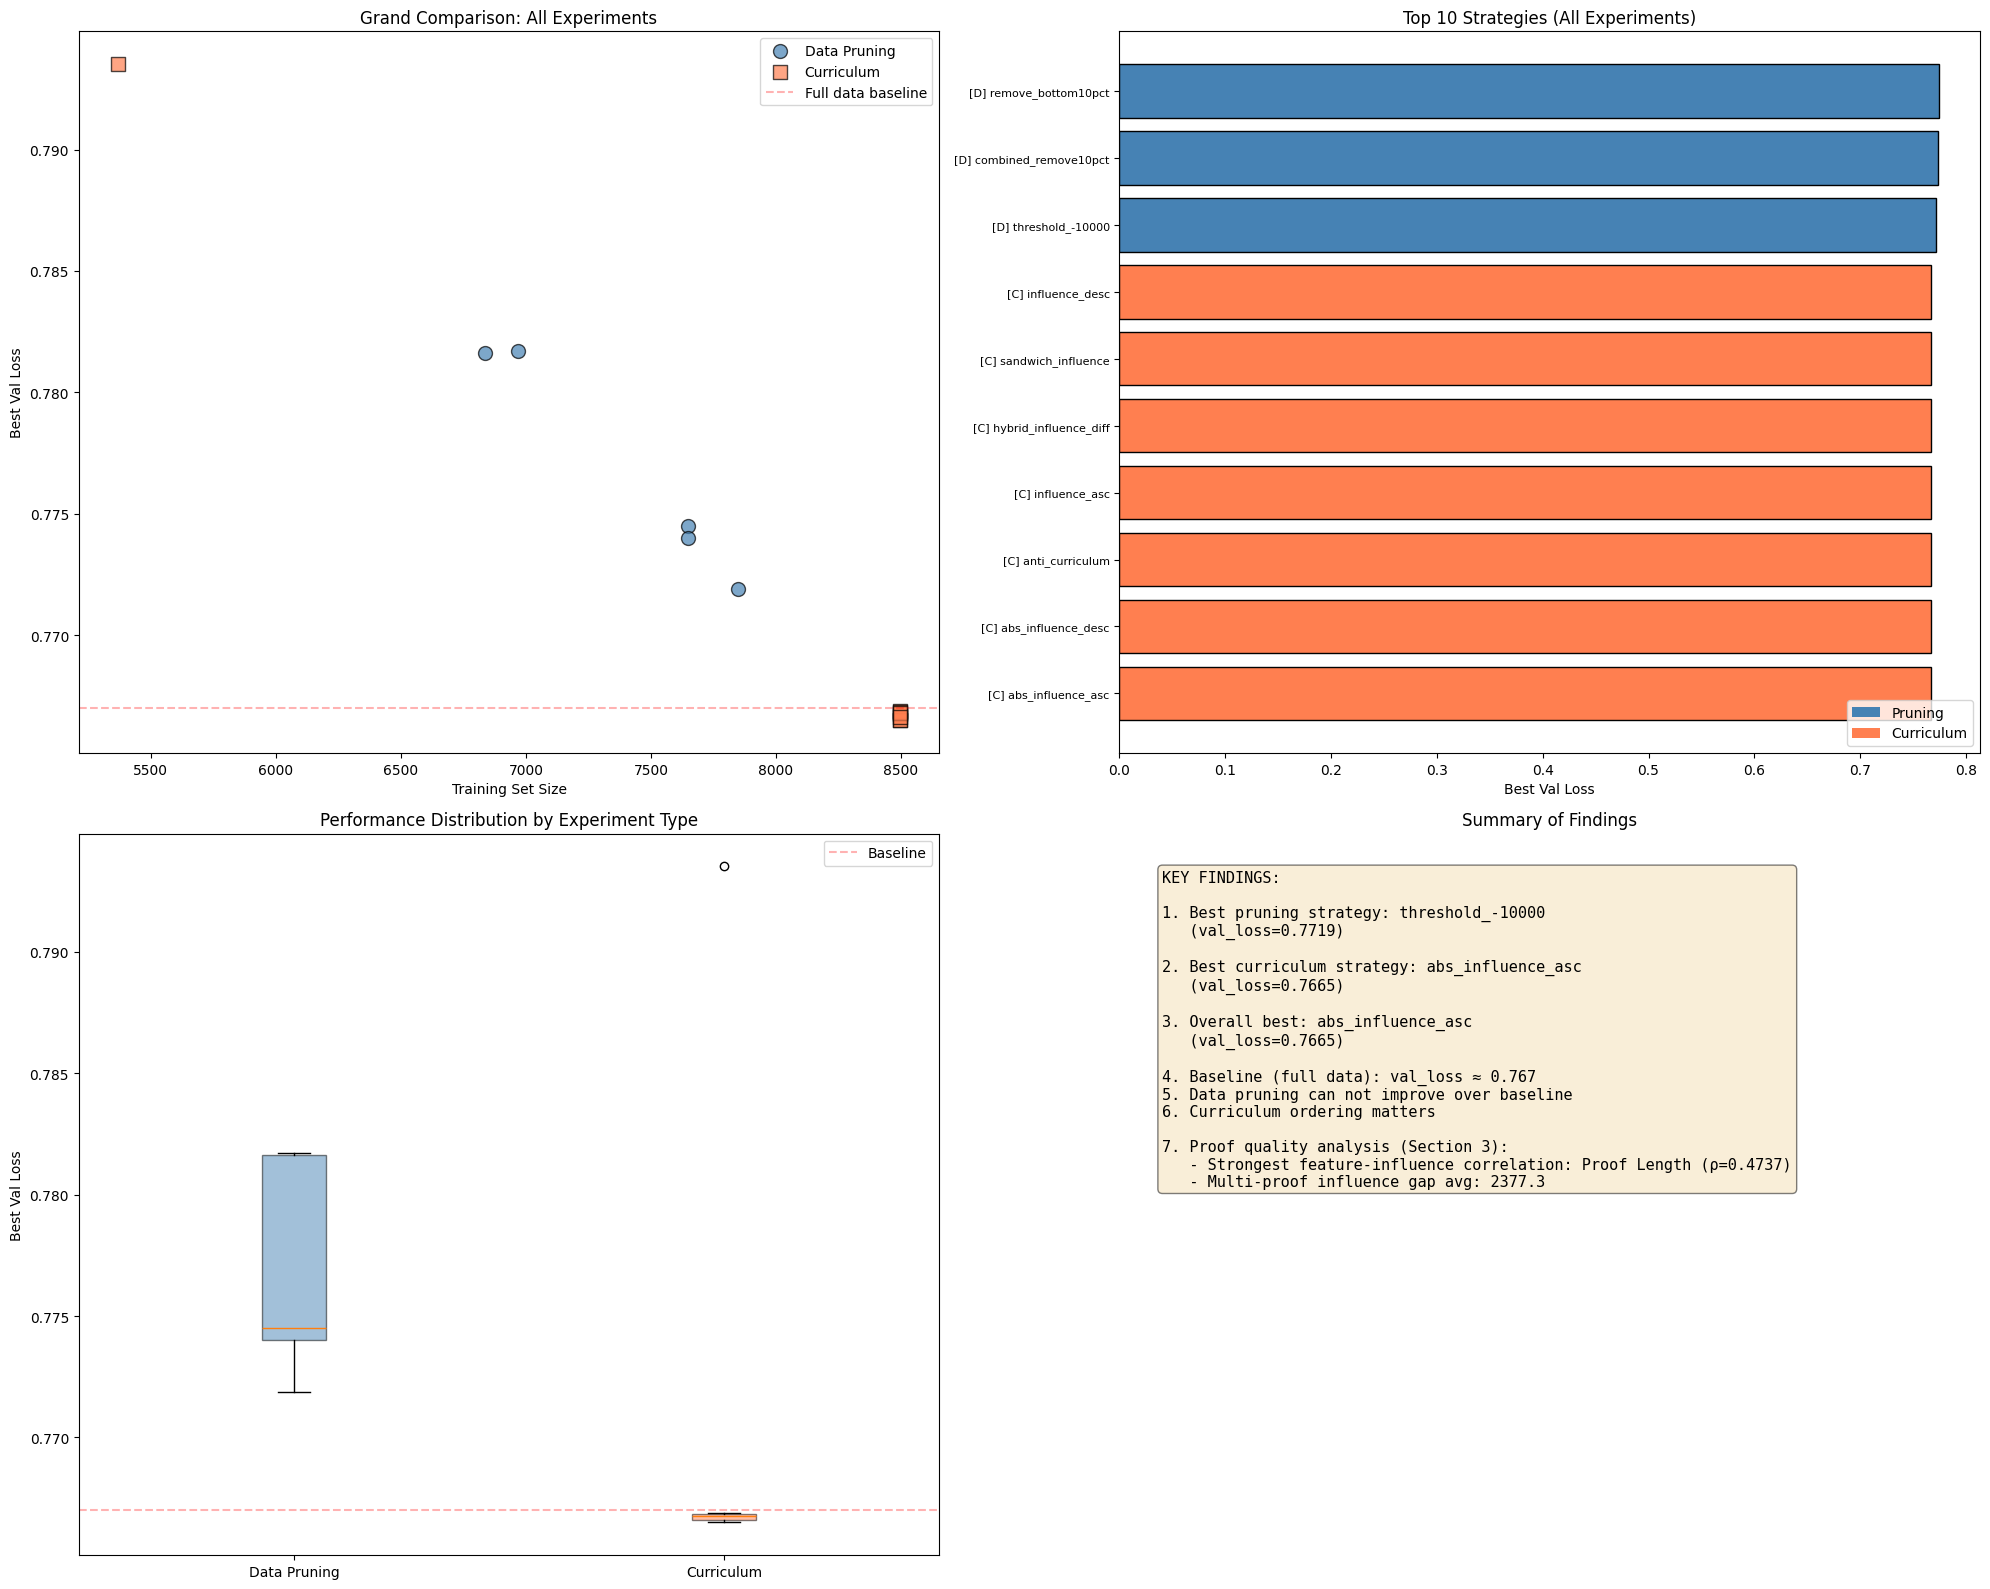


🎉 All experiments completed! Results saved to:
  /content/drive/MyDrive/AIMS5790/outputs/experiments_p2/


In [29]:
# ===== 4.2 Grand Comparison Plot =====

fig, axes = plt.subplots(2, 2, figsize=(20, 16))

# 1. All strategies comparison
ax = axes[0, 0]
for exp_type in ["Data Pruning", "Curriculum"]:
    subset = df_all[df_all["experiment_type"] == exp_type]
    color_map = {"Data Pruning": "steelblue", "Curriculum": "coral"}
    marker_map = {"Data Pruning": "o", "Curriculum": "s"}
    ax.scatter(
        subset["train_size"], subset["val_loss_best"],
        c=color_map[exp_type], marker=marker_map[exp_type],
        s=100, label=exp_type, alpha=0.7, edgecolors='black'
    )
ax.axhline(y=0.767, color='red', linestyle='--', alpha=0.3, label='Full data baseline')
ax.set_xlabel("Training Set Size")
ax.set_ylabel("Best Val Loss")
ax.set_title("Grand Comparison: All Experiments")
ax.legend()

# 2. Top 10 strategies
ax = axes[0, 1]
top10 = df_all.sort_values("val_loss_best").head(10)
y_pos = range(len(top10))
colors_bar = ['steelblue' if t == 'Data Pruning' else 'coral'
              for t in top10["experiment_type"]]
ax.barh(y_pos, top10["val_loss_best"], color=colors_bar, edgecolor='black')
ax.set_yticks(y_pos)
ax.set_yticklabels([f"[{t[:1]}] {s[:25]}" for t, s in zip(top10["experiment_type"], top10["strategy"])], fontsize=8)
ax.set_xlabel("Best Val Loss")
ax.set_title("Top 10 Strategies (All Experiments)")
from matplotlib.patches import Patch
legend_elements = [Patch(facecolor='steelblue', label='Pruning'),
                   Patch(facecolor='coral', label='Curriculum')]
ax.legend(handles=legend_elements, loc='lower right')

# 3. By experiment type: box plot
ax = axes[1, 0]
groups = [df_all[df_all["experiment_type"] == t]["val_loss_best"].dropna().values for t in ["Data Pruning", "Curriculum"]]
bp = ax.boxplot(groups, labels=["Data Pruning", "Curriculum"], patch_artist=True)
for patch, color in zip(bp['boxes'], ['steelblue', 'coral']):
    patch.set_facecolor(color)
    patch.set_alpha(0.5)
ax.axhline(y=0.767, color='red', linestyle='--', alpha=0.3, label='Baseline')
ax.set_ylabel("Best Val Loss")
ax.set_title("Performance Distribution by Experiment Type")
ax.legend()

# 4. Key findings text
ax = axes[1, 1]
ax.axis('off')

findings = [
    "KEY FINDINGS:",
    "",
    f"1. Best pruning strategy: {df_all[df_all['experiment_type']=='Data Pruning'].sort_values('val_loss_best').iloc[0]['strategy']}",
    f"   (val_loss={df_all[df_all['experiment_type']=='Data Pruning'].sort_values('val_loss_best').iloc[0]['val_loss_best']:.4f})",
    "",
    f"2. Best curriculum strategy: {df_all[df_all['experiment_type']=='Curriculum'].sort_values('val_loss_best').iloc[0]['strategy']}",
    f"   (val_loss={df_all[df_all['experiment_type']=='Curriculum'].sort_values('val_loss_best').iloc[0]['val_loss_best']:.4f})",
    "",
    f"3. Overall best: {df_all.sort_values('val_loss_best').iloc[0]['strategy']}",
    f"   (val_loss={df_all.sort_values('val_loss_best').iloc[0]['val_loss_best']:.4f})",
    "",
    f"4. Baseline (full data): val_loss ≈ 0.767",
    f"5. Data pruning can {'improve' if df_all[df_all['experiment_type']=='Data Pruning']['val_loss_best'].min() < 0.767 else 'not improve'} over baseline",
    f"6. Curriculum ordering {'matters' if df_all[df_all['experiment_type']=='Curriculum']['val_loss_best'].std() > 0.005 else 'has minimal effect'}",
    "",
    f"7. Proof quality analysis (Section 3):",
    f"   - Strongest feature-influence correlation: {strongest['feature']} (ρ={strongest['spearman_rho']:.4f})",
    f"   - Multi-proof influence gap avg: {avg_gap:.1f}",
]

ax.text(0.05, 0.95, "\n".join(findings), transform=ax.transAxes, fontsize=11,
        verticalalignment='top', fontfamily='monospace',
        bbox=dict(boxstyle='round', facecolor='wheat', alpha=0.5))
ax.set_title("Summary of Findings")

plt.tight_layout()
plt.savefig(ROOT + "/outputs/experiments_p2/grand_comparison.png", dpi=150)
plt.show()

print("\n🎉 All experiments completed! Results saved to:")
print(f"  {ROOT}/outputs/experiments_p2/")

In [30]:
# ===== Save all results to Drive for later analysis =====
import json

final_report = {
    "pruning_results": {k: {"train_size": v["train_size"], "val_loss_best": v["val_loss_best"], "val_loss_final": v["val_loss_final"]} for k, v in pruning_results.items()},
    "curriculum_results": {k: {"train_size": v["train_size"], "val_loss_best": v["val_loss_best"], "val_loss_final": v["val_loss_final"]} for k, v in curriculum_results.items()},
    "proof_quality_analysis": {
        "tier_analysis": df_tiers.to_dict() if 'df_tiers' in dir() else {},
        "feature_correlations": df_corr.to_dict() if 'df_corr' in dir() else {},
        "multi_proof_summary": df_multi.to_dict() if 'df_multi' in dir() else {},
    },
}

with open(ROOT + "/outputs/experiments_p2/final_report.json", "w") as f:
    json.dump(final_report, f, indent=2, default=str)

print("✅ Final report saved to Drive!")
print(f"  Path: {ROOT}/outputs/experiments_p2/final_report.json")

✅ Final report saved to Drive!
  Path: /content/drive/MyDrive/AIMS5790/outputs/experiments_p2/final_report.json
